# 🚀 Makine Öğrenmesi Reboot Challenge 🚀

Airbnb verisiyle uygulamalı deneyimde bilginizi uygulamaya hazır olun.

Üzerinde çalışacağımız konular:

🧹 Veri Temizleme

🚦 Eğitim-Test Bölme

👷 Pipeline'lar ile doğru şekilde ön işleme

📈 Doğrusal Regresyon

🔁 Çapraz Doğrulama

🎯 İnce Ayar

Hadi başlayıp bu kavramları hayata geçirelim! 🏊‍♀️🏊‍♂️

## 1. Veriyi anlayın 👏 ve temel temizlik 🧹

Bu challenge'da gerçek Airbnb verisi kullanacağız. Bu veri birçok şehirden geliyor. Kodlarımızı yeniden kullanılabilir yapmak isteyeceğiz. Bu şekilde farklı CSV dosyalarıyla hızlı bir şekilde çalışabiliriz, çünkü her CSV için yeni kod yazmamız gerekmeyecek!

### Veriyi yükleme

Öncelikle: ***Asheville, Kuzey Karolina***. CSV dosyası burada mevcut: [🔗 link 🔗](https://d32aokrjazspmn.cloudfront.net/materials/asheville_airbnb.csv).

Sahip olduğumuz tüm bilgilere dayanarak Airbnb konaklama yerinin fiyatını tahmin etmek için doğrusal regresyon kullanacağız!

👉 İlk olarak, CSV dosyasını `df` adlı bir DataFrame'e yükleyelim.
<br><br>
<details><summary><i>💡  İpucu</i></summary>

CSV'deki ilk (isimsiz) sütun aslında bir indeks sütunu. Bu Pandas'ın varsayılan olarak oluşturduğu indeks, ancak zaten bir indeksimiz olduğu için pek faydalı değil!
    
Bundan kurtulmak için, ya `.reset_index()` metodunu kullan, ya da - **daha kolay!** - CSV dosyasını okurken `index_col=0` kullan.

index_col=0'ın ne yaptığını düşünün. Mevcut indeksimiz 3. sütunda olsaydı `index_col` kullanabilir miydik?
</details>

In [1]:
import pandas as pd

url = "https://d32aokrjazspmn.cloudfront.net/materials/asheville_airbnb.csv"

# Load the data into `df`
df = pd.read_csv(url, index_col=0)
df.head()

,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,bedrooms,beds,price,...,number_of_reviews,review_scores_rating,availability_365,instant_bookable,id,listing_url,scrape_id,last_scraped,name,description
0,28801,35.60670,-82.55563,Entire rental unit,Entire home/apt,2,1 bath,1.0,1.0,$120.00,...,90,4.50,285,f,108061,https://www.airbnb.com/rooms/108061,20220611041116,2022-06-11,Walk to stores/parks/downtown. Fenced yard/Pet...,Walk to town in ten minutes! Monthly rental in...
1,28806,35.57864,-82.59578,Entire guesthouse,Entire home/apt,2,1 bath,1.0,1.0,$100.00,...,359,4.58,179,t,155305,https://www.airbnb.com/rooms/155305,20220611041116,2022-06-11,Cottage! BonPaul + Sharky's Hostel,<b>The space</b><br />Private cottage located ...
2,28806,35.57864,-82.59578,Private room in home,Private room,2,2.5 shared baths,1.0,1.0,$66.00,...,67,4.52,0,t,156805,https://www.airbnb.com/rooms/156805,20220611041116,2022-06-11,"Private Room ""Ader"" at BPS Hostel",<b>The space</b><br />Private Rooms at Bon Pau...
3,28806,35.57864,-82.59578,Shared room in hostel,Shared room,1,2.5 shared baths,1.0,6.0,$33.00,...,306,4.71,199,t,156926,https://www.airbnb.com/rooms/156926,20220611041116,2022-06-11,"Mixed Dorm ""Top Bunk #1"" at BPS Hostel",This is a top bunk in the mixed dorm room<br /...
4,28806,35.57808,-82.63689,Private room in home,Private room,2,1 private bath,1.0,1.0,$45.00,...,51,4.98,78,f,197263,https://www.airbnb.com/rooms/197263,20220611041116,2022-06-11,Tranquil Room & Private Bath,"This is a comfy, peaceful and clean room with ..."


👉 DataFrame'inizin dtypes'larını inceleyin. Bir şeyler yanlış. Görüyor musunuz?
<br><br>
<details><summary><i>💡  Çözüm</i></summary>

`price` sütunu bir object, float değil.

</details>

👉 Tanımladığınız sütunu temizleyin.
<br><br>
<details><summary><i>💡  İpucu</i></summary>

[`.str.replace()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.replace.html) ve [`.astype()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.astype.html) metodlarına ihtiyacınız olacak. 
</details>

In [2]:
# YOUR CODE HERE
def clear_price(price_str):
    return float(price_str.replace('$', '').replace(',', ''))
df['price'] = df['price'].apply(clear_price)
df.head()

,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,bedrooms,beds,price,...,number_of_reviews,review_scores_rating,availability_365,instant_bookable,id,listing_url,scrape_id,last_scraped,name,description
0,28801,35.60670,-82.55563,Entire rental unit,Entire home/apt,2,1 bath,1.0,1.0,120.0,...,90,4.50,285,f,108061,https://www.airbnb.com/rooms/108061,20220611041116,2022-06-11,Walk to stores/parks/downtown. Fenced yard/Pet...,Walk to town in ten minutes! Monthly rental in...
1,28806,35.57864,-82.59578,Entire guesthouse,Entire home/apt,2,1 bath,1.0,1.0,100.0,...,359,4.58,179,t,155305,https://www.airbnb.com/rooms/155305,20220611041116,2022-06-11,Cottage! BonPaul + Sharky's Hostel,<b>The space</b><br />Private cottage located ...
2,28806,35.57864,-82.59578,Private room in home,Private room,2,2.5 shared baths,1.0,1.0,66.0,...,67,4.52,0,t,156805,https://www.airbnb.com/rooms/156805,20220611041116,2022-06-11,"Private Room ""Ader"" at BPS Hostel",<b>The space</b><br />Private Rooms at Bon Pau...
3,28806,35.57864,-82.59578,Shared room in hostel,Shared room,1,2.5 shared baths,1.0,6.0,33.0,...,306,4.71,199,t,156926,https://www.airbnb.com/rooms/156926,20220611041116,2022-06-11,"Mixed Dorm ""Top Bunk #1"" at BPS Hostel",This is a top bunk in the mixed dorm room<br /...
4,28806,35.57808,-82.63689,Private room in home,Private room,2,1 private bath,1.0,1.0,45.0,...,51,4.98,78,f,197263,https://www.airbnb.com/rooms/197263,20220611041116,2022-06-11,Tranquil Room & Private Bath,"This is a comfy, peaceful and clean room with ..."


#### Kodunuzu kontrol edin

In [3]:
from nbresult import ChallengeResult

result = ChallengeResult('df',
    df_columns=df.columns,
    price_dtype=df['price'].dtype
)
result.write()

print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/S17D5-S-data-airbnb-prices/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_df.py::TestDf::test_df_has_no_double_index_column PASSED            [ 50%]
test_df.py::TestDf::test_price_has_the_right_dtype PASSED                [100%]

============================== 2 passed in 0.36s ===============================


💯 You can commit your code:

git add tests/df.pickle

git commit -m 'Completed df step'

git push origin master



### Hedef dağılımı

👉 Hedefin dağılımına bir göz atın. Ayrıca minimum ve maksimum değerlerini de kontrol edin.
<br><br>
<details><summary><i>💡  İpucu</i></summary>

Bir pd.Series'in `.hist()` metodunu kullanın. Bunu hedef sütununuza uygulayabilirsiniz. 
</details>

19.0 24999.0


array([[<Axes: title={'center': 'price'}>]], dtype=object)

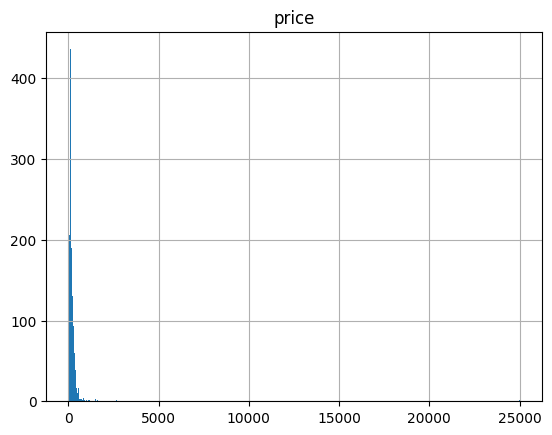

In [4]:
# YOUR CODE HERE
#df.describe()
print(df['price'].min(), df['price'].max())

df.hist(column='price', bins=1000)

Oldukça çarpık görünüyor! 50 ile 1500 dolar arasında (ikisi de dahil) fiyatlandırılmış Airbnb ilanlarına odaklanacağız.

👉 Sadece 50 ile 1500 arasında fiyatlandırılmış ilanları içeren `reduced` adlı bir DataFrame oluşturun.

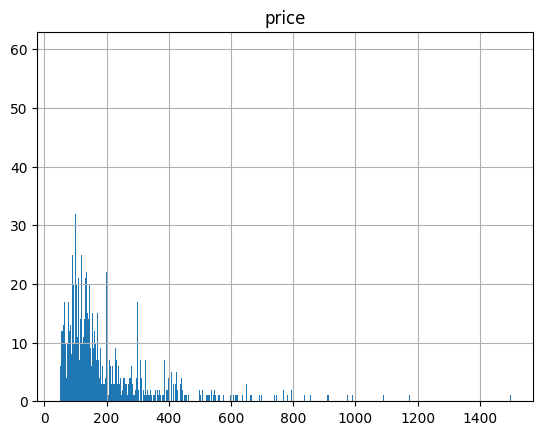

In [5]:
# YOUR CODE HERE
reduced = df[(df["price"] >= 50) & (df["price"] <= 1500)]
reduced.hist(column='price', bins=1000);
#reduced["price"].hist();

In [6]:
reduced.shape

(2766, 21)

#### Kodunuzu kontrol edin

In [7]:
from nbresult import ChallengeResult

result = ChallengeResult('reduced',
    reduced_min=reduced['price'].min(),
    reduced_max=reduced['price'].max(),
    reduced_shape=reduced.shape
)
result.write()

print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/S17D5-S-data-airbnb-prices/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_reduced.py::TestReduced::test_reduced_has_the_right_shape PASSED    [ 50%]
test_reduced.py::TestReduced::test_reduced_min_max PASSED                [100%]

============================== 2 passed in 0.08s ===============================


💯 You can commit your code:

git add tests/reduced.pickle

git commit -m 'Completed reduced step'

git push origin master



### Diğer sütunları temizleyin

👉 `reduced` DataFrame'inizi inceleyin. 

Modellemimize başlamadan önce biraz değiştirmemiz gereken iki sütun var. Hangilerinin olduğunu ve neden olduğunu görüyor musunuz?
<br><br>
<details><summary><i>💡  Çözüm</i></summary>

- `bathrooms_text` sütunu çoğunlukla sayısal bilgiye sahip görünüyor, ancak metin formatında.
- `instant_bookable` sütununda `t` ve `f` değerleri var. Bunun yerine sadece 1'ler ve 0'lar olsa bizim için daha kolay olurdu.
</details>

İlk problemli sütunla başlayalım. 

👉 Sütundaki benzersiz değerlere bir göz atın.

In [8]:
# YOUR CODE HERE
reduced[["bathrooms_text", "instant_bookable"]]
reduced["bathrooms_text"].value_counts()

bathrooms_text
1 bath              1410
2 baths              567
1 private bath       209
2.5 baths            139
3 baths              134
1.5 baths             98
1 shared bath         67
3.5 baths             51
4 baths               38
4.5 baths             10
1.5 shared baths      10
2 shared baths         9
5 baths                8
6 baths                6
5.5 baths              3
2.5 shared baths       2
Half-bath              2
0 shared baths         1
0 baths                1
7 baths                1
Name: count, dtype: int64

İşte temizlik fonksiyonu (sizin için küçük bir 🎁), ancak bunu DataFrame'e kendiniz _uygulamanız_ gerekecek.

In [9]:
def extract_number(text):
    if text.lower() == "half-bath":
        return 0.5
    else:
        return float(text.split(' ')[0])

👉 Sütunu temizlemek için fonksiyonu kullanın ve sonucu aynı sütuna geri kaydedin.

In [10]:
# YOUR CODE HEREredu
reduced["bathrooms_text"] = reduced["bathrooms_text"].apply(extract_number)
reduced[["bathrooms_text", "instant_bookable"]]

/var/folders/32/7brgkn013hjc1zlbmg4kpvfw0000gn/T/ipykernel_6631/493827742.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reduced["bathrooms_text"] = reduced["bathrooms_text"].apply(extract_number)


,bathrooms_text,instant_bookable
0,1.0,f
1,1.0,t
2,2.5,t
5,1.0,f
6,1.0,f
...,...,...
2850,1.0,t
2852,1.0,t
2853,1.0,t
2854,2.0,t


Şimdi diğer sütun üzerinde çalışalım. Değerleri 0'lar ve 1'lere dönüştürmenin birden fazla yolu var. 

👉 Rahat ettiğiniz bir yöntemi seçin (for döngüsü olmadığı sürece...) ve sütunu temizlemek için kullanın.
<br><br>
<details><summary><i>💡  İpucu</i></summary>
    
- [`pandas.Series.map()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html) ile bir eşleme sözlüğü
- [`pandas.Series.apply()`](https://pandas.pydata.org/docs/reference/api/pandas.Series.apply.html) ile lambda fonksiyonu (büyük veri setlerinde yavaş olduğu için önerilmez)
- [`numpy.where()`](https://numpy.org/doc/stable/reference/generated/numpy.where.html)
- Boolean indexing
</details>

In [11]:
# YOUR CODE HERE
reduced["instant_bookable"].map({'t': 1, 'f': 0})

reduced["instant_bookable"].apply(lambda x: 1 if x == 't' else 0)

import numpy as np
np.where(reduced["instant_bookable"] == 't', 1, 0)

(reduced["instant_bookable"]=='t').astype(int)
 
reduced ["instant_bookable"] = (reduced["instant_bookable"]=='t').astype(int)

/var/folders/32/7brgkn013hjc1zlbmg4kpvfw0000gn/T/ipykernel_6631/2424823548.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reduced ["instant_bookable"] = (reduced["instant_bookable"]=='t').astype(int)


#### Kodunuzu kontrol edin

In [12]:
from nbresult import ChallengeResult

result = ChallengeResult('cleaned',
    reduced_shape=reduced.shape,
    bathrooms_text_dtype=reduced['bathrooms_text'].dtype,
    instant_bookable_dtype=reduced['instant_bookable'].dtype,

)
result.write()

print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/S17D5-S-data-airbnb-prices/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 3 items

test_cleaned.py::TestCleaned::test_bathrooms_text_dtype PASSED           [ 33%]
test_cleaned.py::TestCleaned::test_cleaned_has_the_right_shape PASSED    [ 66%]
test_cleaned.py::TestCleaned::test_instant_bookable_dtype PASSED         [100%]

============================== 3 passed in 0.07s ===============================


💯 You can commit your code:

git add tests/cleaned.pickle

git commit -m 'Completed cleaned step'

git push origin master



### Yeniden kullanılabilir bir fonksiyon yapın

Harika! Tüm temizliği yaptık. Peki ya daha sonra bunu başka bir CSV dosyası için yapmak istersek?

👉 Önceki tüm adımları birleştiren bir `df_load_and_clean` fonksiyonu oluşturun. Her şey yolunda giderse, daha önce yaptıklarınızdan sadece kopyala-yapıştır yapmanız yeterli olacak.

In [13]:
def df_load_and_clean(url):
    '''Loads a CSV from the `url` provide and does the basic cleaning
    '''
    # Read the CSV into a dataframe

    df = pd.read_csv(url, index_col=0)

    # Clean and convert price into a float
    df["price"] = df["price"].apply(clear_price)

    # Keep only prices between 50 and 1500
    reduced = df[(df["price"] >= 50) & (df["price"] <= 1500)]

    # Clean and convert bathrooms_text into a float
    reduced["bathrooms_text"] = reduced["bathrooms_text"].apply(extract_number)

    # Convert instant_bookable into 0s and 1s
    reduced["instant_bookable"] = (reduced["instant_bookable"]=='t').astype(int)

    # Return the result
    return reduced

#### Kodunuzu kontrol edin

In [14]:
new_df = df_load_and_clean(url)

/var/folders/32/7brgkn013hjc1zlbmg4kpvfw0000gn/T/ipykernel_6631/4115708634.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reduced["bathrooms_text"] = reduced["bathrooms_text"].apply(extract_number)
/var/folders/32/7brgkn013hjc1zlbmg4kpvfw0000gn/T/ipykernel_6631/4115708634.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reduced["instant_bookable"] = (reduced["instant_bookable"]=='t').astype(int)


In [15]:
from nbresult import ChallengeResult

result = ChallengeResult('load_and_clean',
    new_df=new_df,
    new_shape=new_df.shape,
    price_dtype=new_df['price'].dtype,
    bathrooms_text_dtype=new_df['bathrooms_text'].dtype,
    instant_bookable_dtype=new_df['instant_bookable'].dtype
)
result.write()

print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/S17D5-S-data-airbnb-prices/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 5 items

test_load_and_clean.py::TestLoadAndClean::test_bathrooms_text_dtype PASSED [ 20%]
test_load_and_clean.py::TestLoadAndClean::test_cleaned_has_the_right_shape PASSED [ 40%]
test_load_and_clean.py::TestLoadAndClean::test_instant_bookable_dtype PASSED [ 60%]
test_load_and_clean.py::TestLoadAndClean::test_price_has_the_right_dtype PASSED [ 80%]
test_load_and_clean.py::TestLoadAndClean::test_return PASSED             [100%]

============================== 5 passed in 0.34s ===============================


💯 You can commit your code:

git add tests/load_and_clean.pickle

git commit -m 'Completed load_and_clean step'

git push origi

Harika! Artık sizin için veriyi yükleyen ve temizliği yapan bir fonksiyonunuz var. Bir sonraki adıma geçme zamanı!

## 2. Eğitim-Test Bölme 🚦

### İlgili sütunları seçin

Sütunlara bakın ve sadece doğrusal regresyon görevimizde bize yardımcı olabilecekleri seçin. 

İpucu: bazı sütunlar regresyon görevimiz için gerçekten katma değer sağlamayacak. Bunları çıkarın.

👉 `new_df`'den başlayarak `X` ve `y` oluşturun

In [19]:
# YOUR CODE HERE
new_df.columns

Index(['neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms_text', 'bedrooms', 'beds',
       'price', 'minimum_nights', 'number_of_reviews', 'review_scores_rating',
       'availability_365', 'instant_bookable', 'id', 'listing_url',
       'scrape_id', 'last_scraped', 'name', 'description'],
      dtype='object')

In [21]:
removed_columns = ["id", "listing_url", "scrape_id", "last_scraped", "name", "description", "price"]
X = new_df.drop(columns=removed_columns)
y = new_df["price"]

#### Kodunuzu kontrol edin

In [22]:
from nbresult import ChallengeResult

result = ChallengeResult('x_and_y',
    x_shape=X.shape,
    y_shape=y.shape,
    x_columns=X.columns
)
result.write()

print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/S17D5-S-data-airbnb-prices/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 4 items

test_x_and_y.py::TestXAndY::test_excluded_columns PASSED                 [ 25%]
test_x_and_y.py::TestXAndY::test_target_not_in_x PASSED                  [ 50%]
test_x_and_y.py::TestXAndY::test_x_has_the_right_shape PASSED            [ 75%]
test_x_and_y.py::TestXAndY::test_y_has_the_right_shape PASSED            [100%]

============================== 4 passed in 0.44s ===============================


💯 You can commit your code:

git add tests/x_and_y.pickle

git commit -m 'Completed x_and_y step'

git push origin master



### Eğitim ve test setine bölün

👉 Verinizi eğitim ve test setine bölün.

80/20 bölmesi yapalım.

Ve `42` random state kullanalım. (Son pipeline'ınızda random state'i kaldırmak istersiniz, ama burada sonuçlarımızı karşılaştırmamıza yardımcı olacak.)

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 3. Ön İşleme 👷

Zaten biraz temel temizlik yaptık, ama bazı ön işleme adımlarına ihtiyacımız olacak. Bunları `scikit-learn` kullanarak yapalım. Ön işlemeyi hemen pipeline'lar kullanarak yapacağız.

❓ Neden pipeline'lar kullanmak istiyoruz?

<details>
  <summary><i>Cevap</i>
  </summary>

  1. Ön işleme adımlarımızı güzelce yapılandırmamızı sağlarlar
  2. Ön işleme adımlarımızı eğitim setine fit etmeyi ve eğitim setini, test setini ve modelimize beslemek istediğimiz yeni verileri dönüştürmeyi kolaylaştırırlar
  3. Ön işleme ve model içeren tam bir pipeline'ı düzgün bir şekilde çapraz doğrulama ve grid search yapmamızı sağlayacaklar

</details>

Varsayılan olarak preprocessor'lar NumPy dizileri çıktı verir. Çalışması daha kolay olduğu için Pandas DataFrame'leri çıktı vermeyi tercih ediyoruz.

Numpy dizisi yerine DataFrame formatında çıktı tutmak için transformer'ınızın `.set_output(transform='pandas')` metodunu kullanabilirsiniz.

💡 Ama bunu her transformer için yapmak yerine, bunu global olarak da ayarlayabilirsiniz. Aşağıdaki hücreyi çalıştırın.

In [25]:
from sklearn import set_config
set_config(transform_output="pandas")

### Sayısal özellikler

👉 Sayısal özelliklerle bir liste oluşturun

In [26]:
# İpucu: sütunlarınızı yazdırın ve sonra yeni listenizi oluşturmak için kopyala-yapıştır yapın
# Bir listeden sütun çıkarmak yazmaktan (ve yazım hatalarını düzeltmekten) daha kolay
X_train.columns

Index(['neighbourhood_cleansed', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bathrooms_text', 'bedrooms', 'beds',
       'minimum_nights', 'number_of_reviews', 'review_scores_rating',
       'availability_365', 'instant_bookable'],
      dtype='object')

In [38]:
num_cols = ["latitude", "longitude", "accommodates", 
            "bathrooms_text", "bedrooms", "beds",
            "availability_365",
            "minimum_nights", "number_of_reviews","review_scores_rating"]

#### Eksik değerler

👉 Eksik değerleri inceleyin. Kaç sütunda eksik değer var? Kaç değer eksik?

In [39]:
# YOUR CODE HERE
X_train.isnull().sum()/X_train.count()

neighbourhood_cleansed    0.000000
latitude                  0.000000
longitude                 0.000000
property_type             0.000000
room_type                 0.000000
accommodates              0.000000
bathrooms_text            0.000000
bedrooms                  0.055344
beds                      0.007286
minimum_nights            0.000000
number_of_reviews         0.000000
review_scores_rating      0.071186
availability_365          0.000000
instant_bookable          0.000000
dtype: float64

Bu eksik değerlerle ilgili bir şeyler yapmamız gerekecek. Hangi stratejileri uygulayabilirsiniz?
<br><br>
<details><summary><i>💡  Çözüm</i></summary>

- Eksik değerli sütunları **silin**, ama sadece küçük bir yüzdede eksik değerimiz var. O yüzden bunu yapmayalım.
- Eksik değerli satırları **silin**. Hızlı ve basit, ama çoğu sütun için aslında değerlerimiz var. O yüzden bunu yapmayalım.
- **Eksik değerleri impute edin**: boşlukları doldurun.
</details>

Eksik değerli sütunlara bakın. Her biri için en iyi imputation stratejisi ne olurdu? Kararınızı vermek için her sütunun benzersiz değerlerini kontrol edin.
<br><br>
<details><summary><i>💡  Çözüm</i></summary>

- `bedrooms`: eğer veri yoksa, ayrı bir yatak odası olmadığını varsayabiliriz. Yani 0'larla impute edin.
- `beds`: eğer veri yoksa, yatak olmadığını varsayabiliriz. Yani 0'larla impute edin.
- `review_scores_rating`: eğer veri yoksa, henüz bir rating olmadığını varsayabiliriz ve ortalama rating ile impute edebiliriz. (Bu durumda diğer stratejiler için de argüman sunabilirsiniz. Bir [`KNNImputer`](https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html) burada ilginç olabilir, ama şimdilik basit imputation stratejimize bağlı kalacağız.)
</details>

In [40]:
X_train.head()

,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms_text,bedrooms,beds,minimum_nights,number_of_reviews,review_scores_rating,availability_365,instant_bookable
2198,28806,35.575588,-82.575706,Entire rental unit,Entire home/apt,4,1.0,2.0,2.0,3,43,4.98,36,0
2804,28806,35.569290,-82.612050,Entire home,Entire home/apt,6,2.0,4.0,5.0,30,0,NaN,45,0
2307,28806,35.592520,-82.612850,Entire home,Entire home/apt,5,1.5,3.0,3.0,30,0,NaN,325,1
273,28715,35.514620,-82.650800,Entire cottage,Entire home/apt,7,1.0,3.0,3.0,1,529,4.72,192,1
2132,28715,35.554130,-82.650110,Private room in home,Private room,3,1.0,1.0,1.0,1,109,4.97,147,1


👉 Imputer'larımızı hazırlayalım.

İki farklı stratejimiz olduğu için iki ayrı imputer'a ihtiyacınız olacak: biri 0 imputation için, diğeri ortalama imputation için!

Bunları `zero_imputer` ve `mean_imputer` olarak adlandırın.

In [32]:
from sklearn.impute import SimpleImputer

In [41]:
# Instantiate your zero_imputer and mean_imputer

# YOUR CODE HERE
zero_imputer = SimpleImputer(strategy='constant', fill_value=0)
mean_imputer = SimpleImputer(strategy='mean')

# Make two lists zero_imputer_cols and mean_imputer_cols

# YOUR CODE HERE
zero_imputer_cols = ["bedrooms", "beds"]
mean_imputer_cols = ["review_scores_rating"]

# Each list should contain the column names that will be zero / mean imputed

# YOUR CODE HERE


# This will come in handy later when we will create our pipeline

# YOUR CODE HERE


Şimdi iki imputer'ımızı pipeline'ımızdaki ilk adım olarak bir column transformer'da birleştirebiliriz.

👉 Şunları yapmak için `num_imputer` adlı bir column transformer yapın :
- yukarıda tanımladığımız sütunlarda sıfır impute edin
- diğer tüm sütunları değişmeden ortalama impute edin (ipucu: `remainder` parametresini düşünün)

(Diğer sütunlarda eksik değer yoktu, ama pipeline'ımızı diğer şehirler için de kullanabiliriz. Bu yüzden şimdilik diğer tüm sütunları ortalama impute edeceğiz.)

Sınıf tabanlı yaklaşım (`Pipeline`, `ColumnTransformer`) veya `make_pipeline`, `make_column_transformer` kısayol fonksiyonları arasında seçim yapabilirsiniz.

In [42]:
from sklearn.compose import ColumnTransformer, make_column_transformer

# Create num_imputer
num_imputer = make_column_transformer(
    (zero_imputer, zero_imputer_cols),
    (mean_imputer, mean_imputer_cols),
    remainder="passthrough"
)

# Display num_imputer to check
num_imputer 

ColumnTransformer(remainder='passthrough',
                  transformers=[('simpleimputer-1',
                                 SimpleImputer(fill_value=0,
                                               strategy='constant'),
                                 ['bedrooms', 'beds']),
                                ('simpleimputer-2', SimpleImputer(),
                                 ['review_scores_rating'])])

#### Sayısal özellikleri ölçekleyin

👉 Hangi sütunları ölçeklendirmeniz gerekiyor?

Ayrıca hangi scaler'ı seçeceğinizi görmek için dağılımları kontrol edin. 👉 Aşağıdaki hücreyi çalıştırın.

In [43]:
num_cols

['latitude',
 'longitude',
 'accommodates',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'availability_365',
 'minimum_nights',
 'number_of_reviews',
 'review_scores_rating']

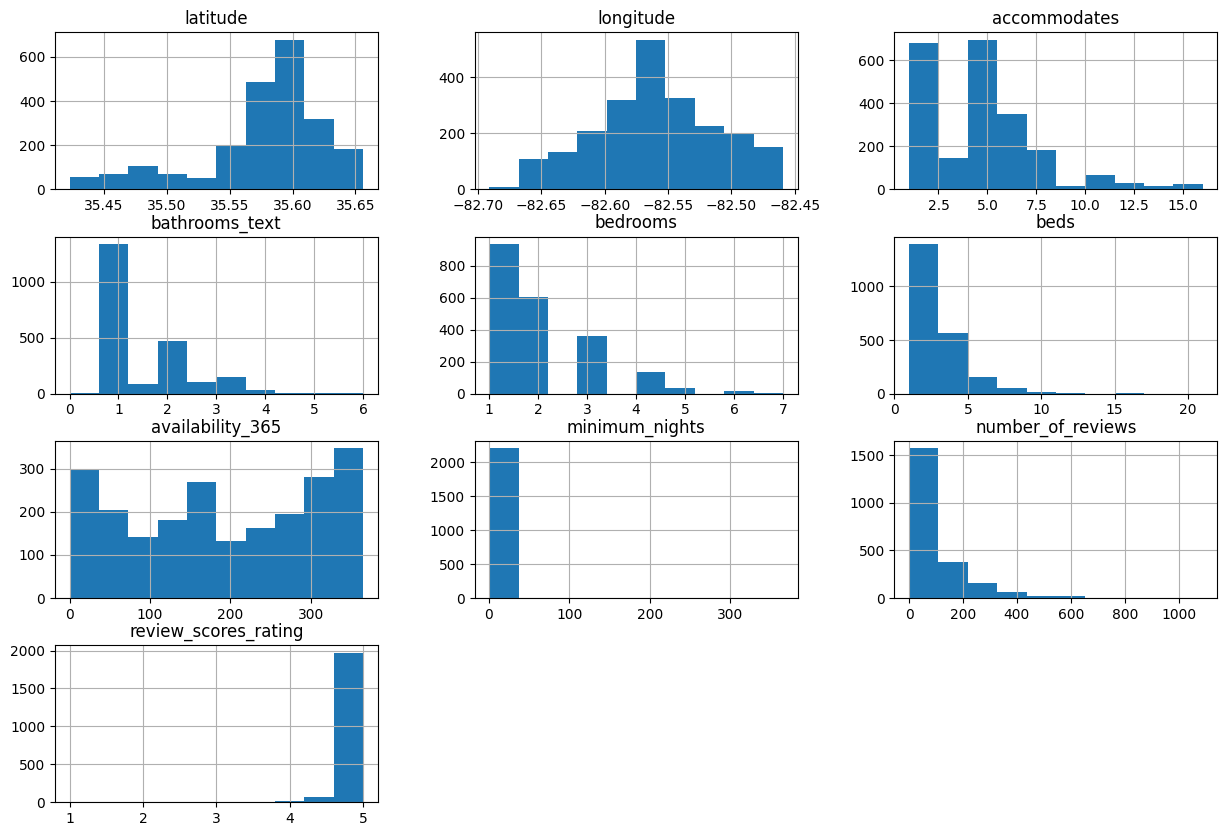

In [44]:
X_train[num_cols].hist(figsize=(15,10));

👉 Uygun bir scaler başlatın. Şimdilik hızlı gitmek için seçtiğimiz tüm sütunları RobustScaler ile ölçeklendireceğiz. Daha sonra bu adıma geri dönmeli ve her sütun için en uygun scaler'ı seçmeliyiz.

In [45]:
from sklearn.preprocessing import RobustScaler

# Instantiate your scaler. Call it `scaler`
# Pro tip: use the .set_output(transform='pandas') method
scaler = RobustScaler().set_output(transform='pandas')

Sayısal özelliklerimiz için bir imputer ve bir scaler oluşturduk. Artık her iki adımı da birleştirmek için bir pipeline oluşturabiliriz.

👉 Şunları yapmak için `num_pipe` adlı bir pipeline yapın :
- `num_imputer`ımızı kullanarak eksik değerleri impute edin
- `scaler`ımızı kullanarak özellikleri ölçekleyin

Sınıf tabanlı yaklaşım (`Pipeline`, `ColumnTransformer`) veya `make_pipeline`, `make_column_transformer` kısayol fonksiyonları arasında seçim yapabilirsiniz.

In [46]:
from sklearn.pipeline import Pipeline, make_pipeline

# Create num_pipe:
# It should first use your num_imputer and then your scaler
num_pipe = make_pipeline(num_imputer, scaler)
# Display num_pipe to check your pipeline
num_pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('simpleimputer-1',
                                                  SimpleImputer(fill_value=0,
                                                                strategy='constant'),
                                                  ['bedrooms', 'beds']),
                                                 ('simpleimputer-2',
                                                  SimpleImputer(),
                                                  ['review_scores_rating'])])),
                ('robustscaler', RobustScaler())])

#### Kodunuzu kontrol edin

In [47]:
from nbresult import ChallengeResult

result = ChallengeResult('scaler',
    num_cols=num_cols,
    X_train_scaled=num_pipe.fit_transform(X_train[num_cols])
)
result.write()

print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/S17D5-S-data-airbnb-prices/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_scaler.py::TestScaler::test_columns_numeric PASSED                  [ 50%]
test_scaler.py::TestScaler::test_has_the_right_shape PASSED              [100%]

============================== 2 passed in 0.39s ===============================


💯 You can commit your code:

git add tests/scaler.pickle

git commit -m 'Completed scaler step'

git push origin master



### Kategorik özellikleri One Hot Encode edin

👉 Hangi sütunları encode etmeniz gerekiyor?

In [51]:
cat_cols = [] # YOUR LIST HERE
cat_cols = ["neighbourhood_cleansed", "property_type", "room_type", "instant_bookable"]

İyi uygulama: her sütunda kaç farklı değeriniz olduğunu kontrol edin.

👉 Bir göz atmak için aşağıdaki hücreyi çalıştırın.

Her değerin encoding'den sonra X'imizdeki bir sütun haline geleceğini unutmayın.

In [52]:
for col in cat_cols:
    display(pd.DataFrame(X_train[col].value_counts()))

,count
neighbourhood_cleansed,
28806,618
28801,511
28804,306
28803,296
28805,210
28704,152
28715,64
28732,55


,count
property_type,
Entire home,732
Entire rental unit,292
Entire guest suite,283
Private room in home,157
Entire condo,137
Entire cabin,87
Entire cottage,86
Entire guesthouse,81
Entire bungalow,64


,count
room_type,
Entire home/apt,1934
Private room,267
Hotel room,10
Shared room,1


,count
instant_bookable,
1,1289
0,923


Bu sütunlardan biri için encoding yaparken biraz akıllı olmamız gerekeceği açık. Yoksa son sonuçta çok fazla sütunumuz olacak.

👉 Oluşturulan sütun sayısını sınırlamak için OneHotEncoder için doğru parametreyi bulun.
<br><br>
<details><summary><i>💡  Çözüm</i></summary>
İki aday var:
<ul>
    <li><strong>max_categories</strong>
    </li>
    <li><strong>min_frequency</strong>
    </li>
</ul>
    İlk iterasyonumuz için <code>max_categories=10</code> kullanalım. Bunu daha sonra değiştirebiliriz.
</details>

👉 Şimdi kategorik özellikleriniz için bir one hot encoder oluşturun

In [53]:
from sklearn.preprocessing import OneHotEncoder

# Instantiate your OneHotEncoder. Call it `encoder`
# Use the .set_output() method again!
encoder = OneHotEncoder(
    max_categories=10,
    handle_unknown='ignore',
    drop="if_binary",
    sparse_output=False).set_output(transform='pandas')

Kategorik özelliklerimiz için bir OneHotEncoder oluşturduk.

Kategorik özelliklerimizde eksik değer olmadığı için bizim durumumuzda bu yeterliydi. Ama unutmayın: pipeline'ımızı diğer şehirler için de kullanabiliriz. Bu yüzden eksik değerler için bir imputer eklemek daha iyi.

👉 Şunları yapmak için `cat_pipe` adlı bir pipeline yapın :
- en sık değerle eksik değerleri impute edin
- `scaler`ımızı kullanarak özellikleri ölçekleyin

`num_pipe`'ınızda kullandığınızdan farklı bir yaklaşım kullanın (sınıf tabanlı vs kısayol fonksiyonu)

In [55]:
from sklearn.pipeline import Pipeline, make_pipeline

# Create cat_pipe:
# It should first apply an imputer and then your scaler
cat_imputer = SimpleImputer(strategy='most_frequent', fill_value='missing')
cat_pipe = Pipeline([
    ('cat_imputer', cat_imputer),
    ('OHE', encoder)
])
# Display cat_pipe to check your pipeline
cat_pipe

Pipeline(steps=[('cat_imputer',
                 SimpleImputer(fill_value='missing', strategy='most_frequent')),
                ('OHE',
                 OneHotEncoder(drop='if_binary', handle_unknown='ignore',
                               max_categories=10, sparse_output=False))])

#### Kodunuzu kontrol edin

In [56]:
from nbresult import ChallengeResult

result = ChallengeResult('encoder',
    cat_cols=cat_cols,
    X_train_encoded=cat_pipe.fit_transform(X_train[cat_cols])
)
result.write()

print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/S17D5-S-data-airbnb-prices/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_encoder.py::TestEncoder::test_columns_categorical PASSED            [ 50%]
test_encoder.py::TestEncoder::test_has_the_right_shape PASSED            [100%]

============================== 2 passed in 0.56s ===============================


💯 You can commit your code:

git add tests/encoder.pickle

git commit -m 'Completed encoder step'

git push origin master



### Sayısal ve kategorik özellikleri tekrar bir araya getirme

Sayısal için bir pipeline'ımız ve kategorik özellikler için bir one-hot-encoder'ımız var. Bunları bir araya getirelim.

👉 Sayısal özellikleri `num_pipe`'ımızdan, kategorik özellikleri `cat_pipe`'ımızdan geçirecek `preprocessor` adlı yeni bir column transformer yapın.

Eğer önceki adımda sınıf tabanlı yaklaşımı (`Pipeline`, `ColumnTransformer`) kullandıysanız, bu sefer `make_pipeline`, `make_column_transformer` kısayol fonksiyonlarına geçin. Ya da tam tersini yapın. Sadece değiştirdiğinizden emin olun 🙃

In [57]:
# Create preprocessor:
# Use num_pipe for the num_cols and cat_pipe for the cat_cols
preprocessor = make_column_transformer(
    (num_pipe, num_cols),
    ( cat_pipe, cat_cols)
)

# Display preprocessor to check your pipeline
preprocessor

/Users/gonul/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('columntransformer',
                                                  ColumnTransformer(remainder='passthrough',
                                                                    transformers=[('simpleimputer-1',
                                                                                   SimpleImputer(fill_value=0,
                                                                                                 strategy='constant'),
                                                                                   ['bedrooms',
                                                                                    'beds']),
                                                                                  ('simpleimputer-2',
                                                                                   SimpleImputer(),
                                                                                   ['review_scores_rating'])])),
                                                 ('robustscaler',
                                                  RobustScaler())]),
                                 ['latitude', 'longitude', '...
                                  'availability_365', 'minimum_nights',
                                  'number_of_reviews',
                                  'review_scores_rating']),
                                ('pipeline-2',
                                 Pipeline(steps=[('cat_imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='most_frequent')),
                                                 ('OHE',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore',
                                                                max_categories=10,
                                                                sparse_output=False))]),
                                 ['neighbourhood_cleansed', 'property_type',
                                  'room_type', 'instant_bookable'])])

Sınıf tabanlı yaklaşım ile `make_***` kısayol fonksiyonları arasındaki farkı görüyor musunuz? 

Sınıf tabanlı yaklaşım farklı adımlar için güzel isimler tanımlamanızı sağlar. Eğer `make_***` kullanırsanız, scikit-learn sizin için ismi belirleyecek. Bu özellikle `ColumnTransformer` kullanırken daha görünür hale gelir.

Ne yaptığımızı özetleyelim:


- **Sayısal** sütunlar için (`num_cols`'umuz):
  - İlk olarak, imputer'larımızı kullanarak eksik değerleri impute ettik:
    - `bedrooms` ve `beds` özellikleri için `zero_imputer`
    - `review_scores_rating` özelliği için `mean_imputer`
    - Diğer sütunlarda eksik değer yoktu, ama preprocessor'ımızı diğer şehirler için de kullanacağımız için hepsini `mean_imputer`'dan da geçirdik
  - İkinci olarak, tüm sayısal özellikleri `scaler`'ımızla ölçeklendirdik
  
  
-  **Kategorik** sütunlar için (`cat_cols`'umuz):
   - Eksik değerleri impute edin. Verilerimizde hiç yoktu, ama yine diğer şehirler için de çalışmasını istiyoruz. En sık değeri impute ediyoruz.
   - `encoder`'ımızla encode edin
  
Pipeline'ımızın nasıl göründüğünün görsel özeti:

<img alt="Pipeline schema" src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/05-ML/Reboot-2/ml-reboot-pipeline.png" width=700>

Eğitim ve test setlerimizi ön işleme tabi tutmak için pipeline'ımızı kullanalım.

Bunları X_train_preprocessed ve X_test_preprocessed'de saklayın.

Muhtemelen birkaç hatayla karşılaşacaksınız. Büyük ihtimalle OneHotEncoder'dan geliyorlar. OneHotEncode'unuz için doğru parametreleri bulup yukarıda değiştirmek size kalmış.

In [58]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)
X_train_preprocessed.shape, X_test_preprocessed.shape

/Users/gonul/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


((2212, 33), (554, 33))

Test setini ön işleme tabi tutarken bilinmeyen kategoriler hakkında UserWarning alırsanız: bu normaldir. Nedenini biliyor musunuz?
<br><br>
<details><summary><i>💡  Çözüm</i></summary>
    OneHotEncoder'ımızı hatırlıyor musunuz?
    <br>
    Eğitim setindeki tüm kategorileri 1'ler ve 0'lar içeren sütunlar halinde encode eder.
    <br>
    Encoder'ın test setinde fit sırasında görmediği kategorilerle karşılaşması mümkün. Bu satırlar için tüm encode edilmiş sütunlar 0 içerecek (çünkü <code>handle_unknown='ignore'</code> seçtik).
</details>

#### Kodunuzu kontrol edin

In [59]:
from nbresult import ChallengeResult

result = ChallengeResult('pipeline',
    X_train_preprocessed=X_train_preprocessed,
    X_test_preprocessed=X_test_preprocessed,
    X_train_to_test_pipeline=preprocessor.fit_transform(X_train),
    X_test_to_test_pipeline_not_fitted_on_test=preprocessor.transform(X_test),
)
result.write()

print(result.check())

/Users/gonul/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/S17D5-S-data-airbnb-prices/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 3 items

test_pipeline.py::TestPipeline::test_has_the_right_shape PASSED          [ 33%]
test_pipeline.py::TestPipeline::test_test_was_only_transformed PASSED    [ 66%]
test_pipeline.py::TestPipeline::test_train_was_transformed PASSED        [100%]

============================== 3 passed in 0.44s ===============================


💯 You can commit your code:

git add tests/pipeline.pickle

git commit -m 'Completed pipeline step'

git push origin master



🚀 Tebrikler! Tam ön işleme pipeline'ınızı oluşturdunuz.

## 4. Modelleme 📈

Artık verimizi ön işleme tabi tutacak bir pipeline'ımız olduğuna göre, sonunda modellemmeye geçebiliriz.

Bir sonraki aşamada 🎯 oynayabileceğimiz bazı parametreler verecek [`ElasticNet`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html#elasticnet) doğrusal regresyon modelini kullanacağız. 

ElasticNet modelinin ne olduğunu hatırlıyor musunuz?
<br><br>
<details><summary><i>💡  Çözüm</i></summary>
    ElasticNet, L1 ve L2 regularization karışımına sahip bir doğrusal regresyon. Temel olarak Ridge ve Lasso regressionı birleştirir.
</details>

👉 Bir ElasticNet modeli başlatın ve `elastic` olarak adlandırın

In [61]:
from sklearn.linear_model import ElasticNet

# Instantiate a model and call it `elastic`
elastic = ElasticNet(random_state=42)

Şimdi çapraz doğrulanmış bir skor elde etmek istiyoruz.

Aşağıdaki hücreye bir göz atın ve hücreyi çalıştırın.

In [62]:
from sklearn.model_selection import cross_val_score

cv_results = cross_val_score(elastic, X_train_preprocessed, y_train, cv=5)
cv_results.mean()

0.5109832606515395

**Ama bir şeyi yanlış yaptık! 😱**

👉 Daha fazla okumadan önce yukarıdaki hücrede nerede hata yaptığımızı düşünmek için bir dakika ayırın.
<br><br>
<details><summary><i>💡  Çözüm</i></summary>
Çapraz doğrulama yaptığımızda, sadece modelleme adımını çapraz doğruladık.

Çapraz doğrulamada eğitim setimiz yeniden bir eğitim ve doğrulama setine bölünür (ve bizim durumumuzda bu 5 kez olur).

Ama ön işleme adımlarımız bu ikinci bölmeden **önce** tüm eğitim setine uygulandı. 
    
Bu, çapraz doğrulama içindeki eğitim ve doğrulama setimiz arasında veri sızıntısı olduğu anlamına gelir.

İdeal olarak, çapraz doğrulamamızın her katı için şunları yapmak istiyoruz:

  - Tüm ön işleme adımlarını eğitim setine fit et
  - Eğitim ve doğrulama setini dönüştür
  - Modeli eğitimde eğit
  - Doğrulama setinde skor al

Şimdiye kadar yaptığımız çapraz doğrulama, ön işlemeyi doğru bir şekilde yapmadı.
</details>

👉 Bunu nasıl çözebiliriz? Bir dakika düşünün.
<br><br>
<details><summary><i>💡  Çözüm</i></summary>
Tüm ön işleme adımlarımız + modelimizle bir pipeline yapıp, sadece modelin yerine bu tam pipeline'ı çapraz doğrulayabiliriz.
    
Bu şekilde çapraz doğrulama her seferinde preprocessor ve modeli sadece eğitim setine fit edecek.
</details>

👉 `preprocessing` pipeline'ınızı `elastic` modelle birleştirerek bir `elastic_pipe` oluşturun

In [63]:
# Create a pipeline with your preprocessor and your model
# Call it `elastic_pipe`
elastic_pipe = make_pipeline(preprocessor, elastic)

# Display elastic_pipe to check your pipeline
elastic_pipe

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('columntransformer',
                                                                   ColumnTransformer(remainder='passthrough',
                                                                                     transformers=[('simpleimputer-1',
                                                                                                    SimpleImputer(fill_value=0,
                                                                                                                  strategy='constant'),
                                                                                                    ['bedrooms',
                                                                                                     'beds']),
                                                                                                   ('simpleimputer-2',
                                                                                                    SimpleImputer(),
                                                                                                    ['review_scores_rating'])])),
                                                                  ('robustscaler',
                                                                   Robust...
                                                   'review_scores_rating']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='most_frequent')),
                                                                  ('OHE',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 max_categories=10,
                                                                                 sparse_output=False))]),
                                                  ['neighbourhood_cleansed',
                                                   'property_type', 'room_type',
                                                   'instant_bookable'])])),
                ('elasticnet', ElasticNet(random_state=42))])

Artık bu pipeline'ı modelleme adımlarımızda kullanabiliriz.

👉 `elastic_pipe`'ı çapraz doğrulayın ve ortalama skorunuzu `cv_score`'da saklayın

Eğitim verilerinizi ayrı ayrı ön işleme tabi tutmanıza gerek olmadığını unutmayın. Ön işleme ve modeli tek bir pipeline'da birleştirdiğimiz için, scikit-learn ön işlemeyi bizim için yapacak.

In [64]:
# Cross-validate it on your training set
cv_results = cross_val_score(elastic_pipe, X_train, y_train, cv=5)
# Save the average score in a variable `cv_score`
cv_score = cv_results.mean()

/Users/gonul/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gonul/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gonul/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gonul/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings

Bilinmeyen kategoriler hakkında birkaç UserWarning alabilirsiniz. Bu normaldir. Nedenini hatırlıyor musunuz?
<br><br>
<details><summary><i>💡  Cevap</i></summary>

OneHotEncoder'ımızı hatırlıyor musunuz?

Eğitim setindeki tüm kategorileri 1'ler ve 0'lar içeren sütunlar halinde encode eder.
    
Doğrulama setinde encoder'ın fit sırasında görmediği kategorilerle karşılaşması olabilir. Bu durumlarda tüm encode edilmiş sütunlar 0 olacak (çünkü `handle_unknown='ignore' seçtik.

Birden fazla uyarı alıyoruz: bunun olduğu her kat için bir tane.
</details>

#### Kodunuzu kontrol edin

In [65]:
from nbresult import ChallengeResult

result = ChallengeResult('linreg_pipe',
    cv_score=cv_score
)
result.write()

print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/S17D5-S-data-airbnb-prices/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_linreg_pipe.py::TestLinregPipe::test_cv_score PASSED                [100%]

============================== 1 passed in 0.10s ===============================


💯 You can commit your code:

git add tests/linreg_pipe.pickle

git commit -m 'Completed linreg_pipe step'

git push origin master



Sonuçlarımıza geri dönelim.

Bu `cv_score` neyi temsil ediyor? Burada hangi metriği kullanıyoruz? Bu skordan memnun musunuz?
<br><br>
<details><summary><i>💡  Çözüm</i></summary>
    Regresyon modelleri için scikit-learn'deki varsayılan skor R<sup>2</sup>.<br>
    Bunun iyi olup olmadığını bilmek için bir baseline'a ihtiyacımız var.
</details>

Bir baseline model oluşturalım. Bu görev için iyi bir baseline ne olurdu?
<br><br>
<details><summary><i>💡  Çözüm</i></summary>
    Regresyon modelleri için yapabileceğimiz en basit şey tahmin olarak ortalamayi kullanmak.
</details>

Baseline modelimizi karşılaştırmak için, onu da gerçek modelimiz gibi çapraz doğrulamalıyız. 

İşte burada scikit-learn'ün [dummy modelleri](https://scikit-learn.org/stable/api/sklearn.dummy.html) işe yarar. Bize basit bir ortalama hesaplamasını gerçek bir scikit-learn modeli olarak kullanma yolu sağlarlar.

👉 Aşağıdaki hücreye bir göz atın ve ne yaptığımızı anlayın.

In [66]:
from sklearn.dummy import DummyRegressor

# Create a baseline_pipe using the baseline model
baseline_pipe = make_pipeline(
    preprocessor,
    DummyRegressor(strategy='mean')
    )

# Cross-validate on the preprocessed training set
baseline_cv_results = cross_val_score(baseline_pipe, X_train, y_train, cv=5)

# Save the average score in a variable `cv_score`
baseline_cv_score = baseline_cv_results.mean()
baseline_cv_score

/Users/gonul/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gonul/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gonul/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gonul/.pyenv/versions/workintech/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings

-0.002110600285393893

Modelimiz baseline'dan daha iyi performans gösteriyor mu?

👉 Cevabınızı "evet" veya "hayır" olarak `better_than_baseline` değişkeninde saklayın.

In [67]:
better_than_baseline = None # Choose between "yes" or "no"
better_than_baseline = "yes" if cv_score > baseline_cv_score else "no"
better_than_baseline

'yes'

#### Kodunuzu kontrol edin

In [68]:
from nbresult import ChallengeResult

result = ChallengeResult('baseline_model',
    better_than_baseline=better_than_baseline
)
result.write()

print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/S17D5-S-data-airbnb-prices/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_baseline_model.py::TestBaselineModel::test_is_better_than_baseline PASSED [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/baseline_model.pickle

git commit -m 'Completed baseline_model step'

git push origin master



Şimdi bu kadar ilerlediğimize göre, bir adım geriye atmamızın zamanı geldi.

Şimdiye kadar ne yaptık:
- **Verilerimizi yüklemek ve temel temizlik yapmak** için bir `df_load_and_clean()` fonksiyonu oluşturduk
- Verilerimizi eğitim ve test setlerine **böldük**
- Pipeline'lar kullanarak bir **preprocessor** oluşturduk:
  - Eksik değerleri impute etme
  - Sayısal özellikleri ölçeklendirme
  - Kategorik özellikleri encode etme
  - Sayısal ve kategorik özellikleri tek bir büyük ön işlenmiş DataFrame'de birleştirme
- Bir **model** başlattık ve bunu pipeline'a ekledik
- Tüm pipeline'ı **çapraz doğruladık**
- Modelimizi bir **baseline** modelle karşılaştırdık (ortalama alma)

## 5. İnce Ayar 🎯

Pipeline'lar ile artık tam pipeline'ın ince ayarını yapmaya başlayabiliriz

Pipeline'ımızda ElasticNet modelini kullanıyoruz. Ayarlayabileceğimiz hiperparametreler nelerdir? [Dokümantasyona](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html#elasticnet) bir göz atın.
<br><br>
<details><summary><i>💡  Çözüm</i></summary>

`alpha`: istediğimiz regularization miktarı

`l1_ratio`: ne kadar L1 regularization istediğimiz (geri kalanı L2 olacak)
</details>

👉 `elastic_pipe`'ınızın ince ayarını yapın ve sonucu `pipe_grid_score`'da saklayın

In [69]:
# Önce ayarlayacağımız doğru parametrenin adını bulun
elastic_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('pipeline-1',
                                    Pipeline(steps=[('columntransformer',
                                                     ColumnTransformer(remainder='passthrough',
                                                                       transformers=[('simpleimputer-1',
                                                                                      SimpleImputer(fill_value=0,
                                                                                                    strategy='constant'),
                                                                                      ['bedrooms',
                                                                                       'beds']),
                                                                                     ('simpleimputer-2',
                                                                                      Si

In [70]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Let's suppress those UserWarnings we talked about before.
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Instantiate a hyperparameter grid with these values:
#     'alpha': [0.1, 1.0, 10.0]
#     'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0]
grid = {
    'elasticnet__alpha': [0.01, 0.1, 1.0],
    'elasticnet__l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0]
}
# Instantiate a GridSearchCV with linreg_pipe and your hyperparameter grid
search = GridSearchCV(estimator=elastic_pipe, param_grid=grid, cv=5)    
# Fit the grid search on X_train, y_train
search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('pipeline-1',
                                                                         Pipeline(steps=[('columntransformer',
                                                                                          ColumnTransformer(remainder='passthrough',
                                                                                                            transformers=[('simpleimputer-1',
                                                                                                                           SimpleImputer(fill_value=0,
                                                                                                                                         strategy='constant'),
                                                                                                                           ['bedrooms',
                                                                                                                            'beds']),
                                                                                                                          ('simpleimputer-2',
                                                                                                                           SimpleImputer(),
                                                                                                                           ['review_scores_rating'...
                                                                                          SimpleImputer(fill_value='missing',
                                                                                                        strategy='most_frequent')),
                                                                                         ('OHE',
                                                                                          OneHotEncoder(drop='if_binary',
                                                                                                        handle_unknown='ignore',
                                                                                                        max_categories=10,
                                                                                                        sparse_output=False))]),
                                                                         ['neighbourhood_cleansed',
                                                                          'property_type',
                                                                          'room_type',
                                                                          'instant_bookable'])])),
                                       ('elasticnet',
                                        ElasticNet(random_state=42))]),
             param_grid={'elasticnet__alpha': [0.01, 0.1, 1.0],
                         'elasticnet__l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0]})

👉 En iyi estimator'ın skorunu grid_best_score'da saklayın ve görüntüleyin

In [71]:
# YOUR CODE HERE
grid_best_params = search.best_params_
grid_best_params

{'elasticnet__alpha': 0.01, 'elasticnet__l1_ratio': 0.75}

👉 En iyi estimator'ın hiperparametrelerini grid_best_score'da saklayın ve görüntüleyin

In [72]:
# YOUR CODE HERE
grid_best_score = search.best_score_
grid_best_score

0.584310071470312

👉 Son olarak, en iyi modeli kullanın ve test setinde skorlayın, bunu `grid_test_score`'a kaydedin

Yeni bir model eğitmeyin, gerek yok: grid search sonuçlarınızdan çıkarabilirsiniz!

In [73]:
# YOUR CODE HERE
grid_test_score = search.best_estimator_.score(X_test, y_test)
grid_test_score

0.460991473705168

👉 GridSearch sonucuna ulaşmak için kaç model eğitti?

Cevabınızı `nb_trainings` değişkeninde saklayın

In [77]:
# YOUR CODE HERE
training_count = 1 + len(grid['elasticnet__alpha']) * len(grid['elasticnet__l1_ratio'])*5
training_count

76

#### Kodunuzu kontrol edin

In [78]:
from nbresult import ChallengeResult

result = ChallengeResult('grid_search',
    best_params=grid_best_params,
    best_score=grid_best_score,
    test_score=grid_test_score,
    training_count=training_count
)
result.write()

print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/gonul/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/gonul/workintech_project/S17D5-S-data-airbnb-prices/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 4 items

test_grid_search.py::TestGridSearch::test_best_params PASSED             [ 25%]
test_grid_search.py::TestGridSearch::test_best_score PASSED              [ 50%]
test_grid_search.py::TestGridSearch::test_test_score PASSED              [ 75%]
test_grid_search.py::TestGridSearch::test_training_count PASSED          [100%]

============================== 4 passed in 0.08s ===============================


💯 You can commit your code:

git add tests/grid_search.pickle

git commit -m 'Completed grid_search step'

git push origin master



## Bunu nasıl daha da ileri götürebiliriz?

Sonundaki grid search'ün biraz temel olduğunu fark etmiş olabilirsiniz.

Ve dürüst olmak gerekirse: daha iyi parametreler bulmak bu model için biraz zorlayıcı. Model underfitting yapıyor gibi görünüyor.

Deneyebileceğimiz ekstra şeyler:

- **Feature engineering**: modelinizin daha iyi performans göstermesini sağlayacak ekstra özellikler ekleyin
  Bazı olanaklar:
  - `price` bölü `bedrooms`
  - Şehir merkezinden uzaklığı hesaplayın (bunu tüm airbnb'lerin enlem ve boylamının ortalaması ile yaklaşık olarak hesaplayabilirsiniz)
  - Bunları pipeline'larınızda kullanmak için özel transformer'lara bakmanız gerekecek (Workflow dersini kontrol edin)
- **Diğer modelleri deneyin**: `KNNRegressor` veya `SVR`
- **Bu modellerin hiperparametrelerini grid search (veya Randomized search) yapın** (örn. `n_neighbours`, `kernel`, `C`)
- **Preprocessor'ların hiperparametrelerini grid search'ünüze ekleyin** (örn. imputation stratejisi)

**Şimdilik bunu yapmayın, çünkü bir sonraki ünitede benzer şeyler yapacağız! 🚀**

🏁 Tebrikler! Başardınız! Makine Öğrenmesi iş akışının tam bir reboot'unu yaptınız!

💾 Notebook'unuzu `git add/commit/push` yapmayı unutmayın...